# **Fairness-Aware Age Estimation: Bias Detection and Mitigation - TASK II**
UB Master in Fundamental Principels of Data Science (2025-2026)

Author: Izel Teker, Ana V. Hernandez

---

## Checking the pytorch version
 - This notebook was successfully tested on version = 2.9.0+cu126

In [1]:
import torch
print(torch.__version__)

2.10.0+cpu


## Importing required libraries

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import csv
from PIL import Image
from timm import create_model
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
from tqdm import tqdm

# **Downloading the Appa-Real Dataset**

- In these practical sessions, we will use the [Appa-Real Dataset](http://chalearnlap.cvc.uab.es/challenge/13/track/13/description/), which consists of face images, age labels, and accompanying metadata. The dataset provides both real and perceived age labels, but in these sessions, we will focus only on the perceived age labels.

- Original RGB images (cropped faces) have pixel values in the range [0, 255], and labels represent ages in the approximate range of 0.9 to 90 years. Later, you will see that **we re-scale the age values to the range [0, 1]** to simplify operations (e.g., training), and eventually re-scale the output back during evaluation **using a predefined normalization factor**.

- Metadata is also provided with the dataset:
  - **Gender:** male / female  
  - **Ethnicity:** asian / afroamerican / caucasian  
  - **Facial expression:** neutral / slightly happy / happy / other

- You can see the data we have downloaded and the structure of Colab by clicking on 'Files', on the left side (<--) of this interface.  

- The data is divided into **train**, **validation**, and **test** sets. However, **you MUST NOT use the Test set to tune hyperparameters, training strategies, or to improve/define your model(s). All preliminary experiments MUST be conducted using the TRAINING and VALIDATION data.** Test data will be used only to generate the final results after the best model is defined based on the validation set.

  - For example, imagine you evaluate models "A", "B", "C", and "D" on the validation data. If the best results are obtained using model "C", then **model "C" is your final model**, and only then you compute and report the final results on the Test set.

- You can train your models using the provided train and validation sets, as done in this starting kit, or define your own train/validation split. For instance, you could merge the provided train and validation data and randomly split them differently. You are free to design any training strategy. **Your creativity will have a significant impact on evaluation.**


# **Defining the Data Loader Class**
- In this example, metadata information is loaded but not used. Future implementations can take benefit of it.
- Note that age labels are divided by 100 (assuming 100 is the max age found in the dataset) so that the age values can be normalized to be in the range of 0 and 1. This way, we can add a sigmoid activation in the last layer of our model.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!cp "/content/drive/MyDrive/appa-real-dataset_v2.zip" /content/
!cp "/content/drive/MyDrive/UTKFace.zip" /content/
!unzip appa-real-dataset_v2.zip -d /content/
!unzip UTKFace.zip -d /content/
# /content/appa-real-dataset_v2/

Streaming output truncated to the last 5000 lines.
  inflating: /content/UTKFace/30_1_0_20170117143902329.jpg.chip.jpg  
  inflating: /content/__MACOSX/UTKFace/._30_1_0_20170117143902329.jpg.chip.jpg  
  inflating: /content/UTKFace/41_0_0_20170116214404363.jpg.chip.jpg  
  inflating: /content/__MACOSX/UTKFace/._41_0_0_20170116214404363.jpg.chip.jpg  
  inflating: /content/UTKFace/58_0_1_20170113193258196.jpg.chip.jpg  
  inflating: /content/__MACOSX/UTKFace/._58_0_1_20170113193258196.jpg.chip.jpg  
  inflating: /content/UTKFace/36_1_1_20170116155035948.jpg.chip.jpg  
  inflating: /content/__MACOSX/UTKFace/._36_1_1_20170116155035948.jpg.chip.jpg  
  inflating: /content/UTKFace/25_0_0_20170113181532013.jpg.chip.jpg  
  inflating: /content/__MACOSX/UTKFace/._25_0_0_20170113181532013.jpg.chip.jpg  
  inflating: /content/UTKFace/66_1_0_20170110123144558.jpg.chip.jpg  
  inflating: /content/__MACOSX/UTKFace/._66_1_0_20170110123144558.jpg.chip.jpg  
  inflating: /content/UTKFace/40_0_1_201701

In [5]:
!cp "/content/drive/MyDrive/utk_filtered.csv" /content/

In [6]:
import os
import torch
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image


class AgeEstimationDataset(Dataset):
    def __init__(
        self,
        appa_dir,
        utk_dir,
        csv_file,
        base_transforms=None,
        strong_transforms=None,
        age_normalization_factor=100.0
    ):
        self.appa_dir = appa_dir
        self.utk_dir = utk_dir
        self.base_transforms = base_transforms
        self.strong_transforms = strong_transforms

        self.data_info = pd.read_csv(csv_file)

        self.age_norm = age_normalization_factor

        # Integer encoding
        self.gender_map = {"male": 0, "female": 1}

        self.eth_map = {
            "asian": 0,
            "afroamerican": 1,
            "caucasian": 2,
            "other": 3
        }

        self.exp_map = {
            "neutral": 0,
            "slightlyhappy": 1,
            "happy": 2,
            "other": 3,
            "unknown": 4
        }

        # Dataset weighting
        self.source_weights = {
            "appa": 1.0,
            "utk": 0.6
        }

    def __len__(self):
        return len(self.data_info)

    def _resolve_image_path(self, row):
        source = row["source"]
        raw_file = row["imageid"]

        if source == "appa":
            image_id = f"{int(float(raw_file)):06d}.jpg"
            return os.path.join(self.appa_dir, image_id)

        elif source == "utk":
            return os.path.join(self.utk_dir, str(raw_file))

        else:
            raise ValueError(f"Unknown dataset source: {source}")

    def __getitem__(self, idx):

        row = self.data_info.iloc[idx]

        # -------------------------
        # Image
        # -------------------------
        image_path = self._resolve_image_path(row)

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error loading image: {image_path}") from e

        # -------------------------
        # Raw metadata
        # -------------------------
        raw_age = float(row["age"])
        raw_ethnicity = row["ethnicity"]
        exp_label = row["expression"]

        # UTK has no expression
        if row["source"] == "utk":
            exp_label = "unknown"


        # -------------------------
        # Transforms
        # -------------------------
        if self.base_transforms is not None:
            image = self.base_transforms(image)

        # -------------------------
        # Target
        # -------------------------
        age = torch.tensor(raw_age / self.age_norm, dtype=torch.float32)

        # -------------------------
        # Encoded metadata
        # -------------------------
        gender = self.gender_map.get(row["gender"], 0)
        ethnicity = self.eth_map.get(raw_ethnicity, 3)
        meta = torch.tensor(
            [gender, ethnicity],
            dtype=torch.long
        )

        # -------------------------
        # Sample weight
        # -------------------------
        source = row["source"]
        sample_weight = torch.tensor(
            self.source_weights[source],
            dtype=torch.float32
        )

        return image, age, meta, sample_weight

In [7]:
# --- Process APPA Train ---
df_appa = pd.read_csv("/content/appa-real-dataset_v2/labels_metadata_train.csv")
df_appa.columns = ['imageid', 'age', 'gender', 'ethnicity', 'expression']
df_appa['source'] = 'appa'

# --- Process UTK (Filtered) ---
df_utk = pd.read_csv("/content/utk_filtered.csv")
df_utk.columns = ['imageid', 'age', 'gender', 'ethnicity', 'expression']
df_utk['source'] = 'utk'

# --- Combine ---
df_train_combined = pd.concat([df_appa, df_utk], ignore_index=True)
df_train_combined.to_csv("train_final.csv", index=False)

# --- Process APPA Valid ---
df_valid = pd.read_csv("/content/appa-real-dataset_v2/labels_metadata_valid.csv")
df_valid.columns = ['imageid', 'age', 'gender', 'ethnicity', 'expression']
df_valid['source'] = 'appa'
df_valid.to_csv("valid_final.csv", index=False)

# **Defining the base image transformations**

In [8]:
base_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# **Loading the Train and Validation sets**

In [9]:
# Create dataset and dataloader (train set):

APPA_TRAIN = "/content/appa-real-dataset_v2/train_data"
APPA_VALID = "/content/appa-real-dataset_v2/valid_data"
UTK_PATH = "./UTKFace"


# TRAINING SET
dataset_train = AgeEstimationDataset(
    appa_dir=APPA_TRAIN,
    utk_dir=UTK_PATH,
    csv_file="train_final.csv",
    base_transforms=base_transforms,
)

dataloader_train = DataLoader(
    dataset_train,
    batch_size=64,
    num_workers=2,
    pin_memory=True,
    shuffle=True
)

# VALIDATION SET (APPA Only)
dataset_valid = AgeEstimationDataset(
    appa_dir=APPA_VALID,
    utk_dir="", # Not used
    csv_file="valid_final.csv",
    base_transforms=base_transforms
)

dataloader_valid = DataLoader(dataset_valid, batch_size=64, shuffle=False)

In [10]:
class AgeDistributionLoss(nn.Module):
    def __init__(self, sigma=2.0, max_age=100, reduction='none'):
        super().__init__()
        self.sigma = sigma
        self.max_age = max_age
        self.reduction = reduction
        self.register_buffer("age_bins", torch.arange(max_age + 1).float())

    def forward(self, logits, ages):
        # Generate Gaussian targets
        dist = (self.age_bins.unsqueeze(0) - ages.unsqueeze(1)) ** 2
        target = torch.exp(-dist / (2 * self.sigma ** 2))

        # Normalize with epsilon to prevent 0/0
        target = target / (target.sum(dim=1, keepdim=True) + 1e-8)

        # KL-Divergence / Cross-Entropy logic
        log_probs = torch.log_softmax(logits, dim=1)
        loss = -(target * log_probs).sum(dim=1)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss # Returns [Batch_Size] for sample_weight multiplication

# **Plotting age, gender, ethnicity, and emotion distributions in the training set**

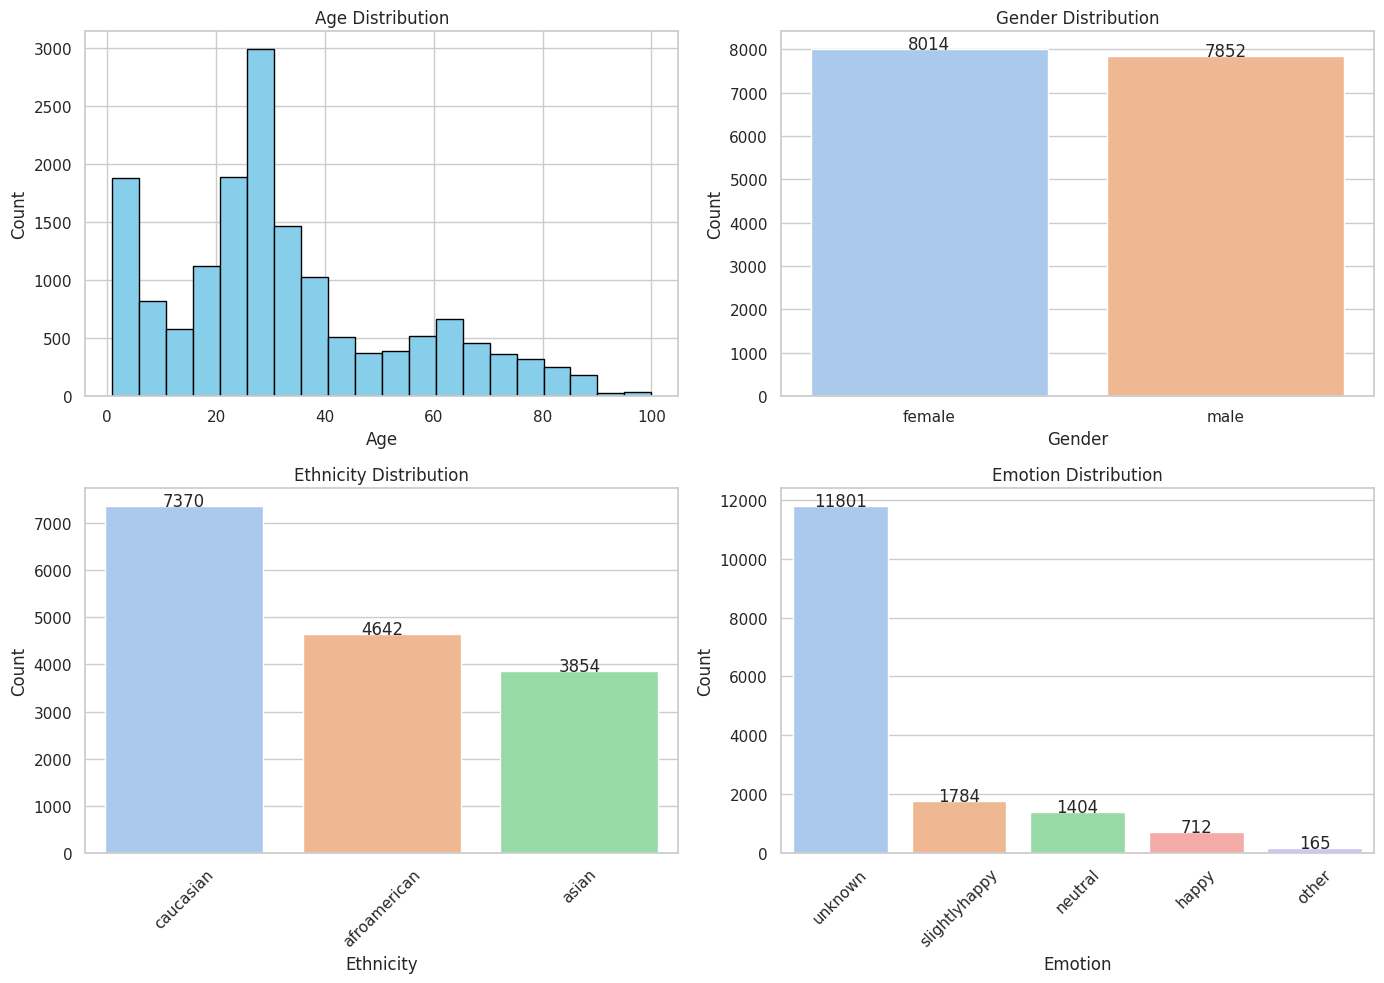

In [11]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("./train_final.csv")
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age distribution
axes[0, 0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# 2. Gender distribution
gender_df = df['gender'].value_counts().reset_index()
gender_df.columns = ['gender', 'count']
# Add a dummy hue column for compatibility
gender_df['hue'] = gender_df['gender']
sns.barplot(data=gender_df, x='gender', y='count', hue='hue', palette='pastel', dodge=False, ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xlabel("Gender")
for i, v in enumerate(gender_df['count']):
    axes[0, 1].text(i, v + 0.5, str(v), ha='center')

# 3. Ethnicity distribution
ethnicity_df = df['ethnicity'].value_counts().reset_index()
ethnicity_df.columns = ['ethnicity', 'count']
ethnicity_df['hue'] = ethnicity_df['ethnicity']
sns.barplot(data=ethnicity_df, x='ethnicity', y='count', hue='hue', palette='pastel', dodge=False, ax=axes[1, 0], legend=False)
axes[1, 0].set_title("Ethnicity Distribution")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xlabel("Ethnicity")
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(ethnicity_df['count']):
    axes[1, 0].text(i, v + 0.5, str(v), ha='center')

emotion_df = df['expression'].value_counts().reset_index()
emotion_df.columns = ['emotion', 'count']
emotion_df['hue'] = emotion_df['emotion']
sns.barplot(data=emotion_df, x='emotion', y='count', hue='hue', palette='pastel', dodge=False, ax=axes[1, 1], legend=False)
axes[1, 1].set_title("Emotion Distribution")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xlabel("Emotion")
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(emotion_df['count']):
    axes[1, 1].text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.show()


# **Loading the pretrained ViT baselone model and adapting it to our problem**

- ViT normally outputs class scores for classification tasks; here, we adapt it for regression by setting **num_classes=1**.

> **Note:** This notebook is intended as a starting point. For your deliverables, avoid making only minor modifications. Instead, explore your creativity and try more substantial improvements.



In [12]:
import torch
import torch.nn as nn
from timm import create_model


class AgeEstimationConvnext(nn.Module):

    def __init__(self, max_age=100):

        super().__init__()

        self.max_age = max_age
        self.num_bins = max_age + 1

        # ------------------------------------------------
        # Backbone
        # ------------------------------------------------
        self.backbone = create_model(
            "convnext_tiny",
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        feat_dim = self.backbone.num_features  # 768

        # ------------------------------------------------
        # Metadata embeddings
        # ------------------------------------------------
        self.gender_emb = nn.Embedding(2, 16)
        self.eth_emb = nn.Embedding(4, 16)

        meta_dim = 32

        self.meta_encoder = nn.Sequential(
            nn.Linear(meta_dim, 128),
            nn.GELU(),
            nn.LayerNorm(128),
            nn.Dropout(0.2)
        )

        # ------------------------------------------------
        # FiLM conditioning
        # ------------------------------------------------
        self.film = nn.Linear(128, feat_dim * 2)

        # ------------------------------------------------
        # Age distribution head
        # ------------------------------------------------
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, self.num_bins)
        )

        # age index buffer
        self.register_buffer(
            "age_bins",
            torch.arange(self.num_bins).float()
        )

    def forward(self, x, meta):

        # ---------------------------------------------
        # Image features
        # ---------------------------------------------
        feat = self.backbone(x)

        # ---------------------------------------------
        # Metadata
        # ---------------------------------------------
        g = self.gender_emb(meta[:, 0])
        e = self.eth_emb(meta[:, 1])

        meta_feat = torch.cat([g, e], dim=1)
        meta_feat = self.meta_encoder(meta_feat)

        # ---------------------------------------------
        # FiLM conditioning
        # ---------------------------------------------
        gamma_beta = self.film(meta_feat)

        gamma, beta = gamma_beta.chunk(2, dim=1)

        feat = gamma * feat + beta

        # ---------------------------------------------
        # Predict distribution
        # ---------------------------------------------
        logits = self.head(feat)

        probs = torch.softmax(logits, dim=1)

        # expected age
        age = torch.sum(probs * self.age_bins, dim=1)

        return age, logits

In [13]:
# creating the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AgeEstimationConvnext().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

# Defining an auxiliary function to plot the training history

In [14]:
# Function to plot training curves
def plot_training_curves(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid()
    plt.show()

# **Defining the Training function**
- Our training code includes **early stopping** and **automatic saving of the best model**. Early stopping monitors the validation loss during training and halts training if the model stops improving for a specified number of epochs, helping to prevent overfitting and save computational resources. At the same time, the model with the lowest validation loss is automatically saved, ensuring that we keep the best-performing version for evaluation or deployment.

In [15]:
import copy
import torch
from tqdm import tqdm

def train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler,
    num_epochs,
    patience,
    model_path,
    device
):
    best_mae = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    early_counter = 0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0
            running_mae = 0
            n_samples = 0
            loader = dataloaders[phase]

            with tqdm(loader, desc=f"{phase.upper()}") as t:
                for images, labels_norm, meta, sample_weight in t:
                    images = images.to(device)
                    targets = (labels_norm * 100.0).to(device)
                    meta = meta.to(device)
                    sample_weight = sample_weight.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == "train"):
                        with torch.cuda.amp.autocast():
                            age_pred, logits = model(images, meta)

                            loss_vector = criterion(logits, targets)

                            # Apply sample weights (UTK vs APPA weighting)
                            weighted_loss = (loss_vector * sample_weight).mean()

                        if phase == "train":
                            scaler.scale(weighted_loss).backward()
                            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                            scaler.step(optimizer)
                            scaler.update()

                    mae = torch.abs(age_pred - targets)

                    running_loss += weighted_loss.item() * images.size(0)
                    running_mae += mae.sum().item()
                    n_samples += images.size(0)

                    t.set_postfix(
                        loss=weighted_loss.item(),
                        mae=(running_mae / n_samples)
                    )

            epoch_loss = running_loss / n_samples
            epoch_mae = running_mae / n_samples

            print(f"{phase} Loss: {epoch_loss:.4f} | MAE: {epoch_mae:.3f} years")

            if phase == "val":
                # Step the scheduler based on MAE or Loss
                scheduler.step(epoch_mae)

                if epoch_mae < best_mae:
                    best_mae = epoch_mae
                    best_weights = copy.deepcopy(model.state_dict())
                    torch.save(best_weights, model_path)
                    print(f"✔ Saved best model (MAE: {best_mae:.3f})")
                    early_counter = 0
                else:
                    early_counter += 1
                    if early_counter >= patience:
                        print("\nEarly stopping triggered")
                        model.load_state_dict(best_weights)
                        return model

    model.load_state_dict(best_weights)
    return model

# **Training the Model (or Loading a Pre-Trained Model)**

- If `MODEL_TRAIN = False`, the code will load a pre-trained model that was trained using the provided training code.

- To perform training (fine tunning the model pretrained on ImageNet), set `MODEL_TRAIN = True`.  

  - The code uses **early stopping** with `patience = 10`, meaning that training will stop if the validation loss does not improve for 10 consecutive epochs.  
  - The **loss function** is **Mean Squared Error (MSE)** (`criterion = nn.MSELoss()`).  
  - Training hyperparameters include: **learning rate = 1e-5**, **batch size = 32**, and **number of epochs = 50** (adjustable depending on your Colab runtime).  
  - The **model checkpoint callback** saves the best model based on validation loss. Best model will be saved on Google Drive, given the path defined by `model_filename`.
  - Other hyperparameters you can experiment with include the optimizer, loss function, learning rate, batch size, and number of epochs.  



In [16]:
def set_backbone_freeze(model, freeze=True):
    for param in model.backbone.parameters():
        param.requires_grad = not freeze
    # Ensure the multimodal parts stay unfrozen during warm-up
    for module in [model.gender_emb, model.eth_emb, model.meta_encoder, model.film, model.head]:
        for param in module.parameters():
            param.requires_grad = True

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==========================================
# CONFIGURATION
# ==========================================
MODEL_TRAIN = True
model_filename = "./age_model_with_extended_data_customloss.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AgeEstimationConvnext().to(device)
criterion = AgeDistributionLoss().to(device)
dataloaders = {"train": dataloader_train, "val": dataloader_valid}

if MODEL_TRAIN:
    # ---------------------------------------------------------
    # STAGE 1: Warm-up (Head Only)
    # ---------------------------------------------------------
    print("\n>>> STAGE 1: Training the Multimodal Head (Backbone Frozen)")
    set_backbone_freeze(model, freeze=True)

    optimizer_v1 = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=1e-4, weight_decay=0.01)

    scheduler_v1 = ReduceLROnPlateau(optimizer_v1, mode='min', patience=2)

    # Short warm-up phase
    model = train_model(model, dataloaders, criterion, optimizer_v1,
                        scheduler_v1, num_epochs=10, patience=3,
                        model_path=model_filename, device=device)

    # ---------------------------------------------------------
    # STAGE 2: Fine-Tuning (Full Model)
    # ---------------------------------------------------------
    print("\n>>> STAGE 2: Fine-Tuning Entire Model (Backbone Unfrozen)")
    set_backbone_freeze(model, freeze=False)

    optimizer_v2 = AdamW([
        {"params": model.backbone.parameters(), "lr": 1e-5}, 
        {"params": model.gender_emb.parameters(), "lr": 1e-4},
        {"params": model.eth_emb.parameters(), "lr": 1e-4},
        {"params": model.meta_encoder.parameters(), "lr": 1e-4},
        {"params": model.film.parameters(), "lr": 1e-4},
        {"params": model.head.parameters(), "lr": 1e-4},
    ], weight_decay=0.01)

    scheduler_v2 = ReduceLROnPlateau(optimizer_v2, mode='min', patience=3)

    # Full training phase
    model = train_model(model, dataloaders, criterion, optimizer_v2,
                        scheduler_v2, num_epochs=30, patience=5,
                        model_path=model_filename, device=device)

else:
    # LOAD PRE-TRAINED MODEL
    print(f"Loading weights from {model_filename}...")
    model.load_state_dict(torch.load(model_filename, map_location=device, weights_only=True))

    # Display previous training history if available
    try:
        from PIL import Image
        import matplotlib.pyplot as plt
        img = Image.open('./ViTbaseline_train_history.png')
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print("Training history image not found.")

/tmp/ipykernel_907/3106142668.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(



>>> STAGE 1: Training the Multimodal Head (Backbone Frozen)

Epoch 1/10
----------------------------------------


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_907/3106142668.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
TRAIN:   1%|          | 2/248 [00:33<1:08:17, 16.65s/it, loss=3.12, mae=26]

# **Defining an auxiliary function to evaluate the model**
- We evaluate the model using the Mean Absolute Error as matric (MAE)

- The train/validation labels were re-scaled to be in the range of [0,1] for training and the predictions will be in the same range [0,1] (given the Sigmoid Activation in the last layer). Thus, we re-scale them back (to be in the range of "ages") to facilitate the analysis.

- The function also generates a ***submission file*** (.zip) that can be uploaded to our challenge, when the test set is being evaluated.

- The generated submission file can be downloaded from the left side (<--) of this interface.

In [ ]:
from zipfile import ZipFile
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

def predict_and_evaluate(model_path, test_dataset, output_zip=None, batch_size=32):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize and load the model
    model = AgeEstimationConvnext().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    results_df = test_dataset.data_info.copy()

    preds_real = []

    with torch.no_grad():
        for images, _, metadata, _ in tqdm(test_loader, desc="Predicting"):

            images = images.to(device)
            metadata = metadata.to(device)

            age_pred, _ = model(images, metadata)

            preds_real.extend(age_pred.cpu().numpy())

    # --------------------------------------------------
    # Results Processing
    # --------------------------------------------------
    results_df["predicted_age"] = np.array(preds_real)
    results_df["actual_age"] = results_df["age"].astype(float)

    results_df["abs_error"] = np.abs(
        results_df["predicted_age"] - results_df["actual_age"]
    )

    # --------------------------------------------------
    # BIAS CALCULATION
    # --------------------------------------------------
    def get_bias(column_name):
        group_maes = results_df.groupby(column_name)["abs_error"].mean()
        return group_maes.std(), group_maes.to_dict()

    gender_bias, g_dict = get_bias("gender")
    eth_bias, e_dict = get_bias("ethnicity")

    # Age bins
    results_df["age_bin"] = pd.cut(
        results_df["actual_age"],
        bins=[0, 20, 40, 60, 100]
    )

    age_bias = (
        results_df
        .groupby("age_bin", observed=True)["abs_error"]
        .mean()
        .std()
    )

    avg_mae = results_df["abs_error"].mean()
    avg_bias = (gender_bias + eth_bias + age_bias) / 3

    # --------------------------------------------------
    # PRINT METRICS
    # --------------------------------------------------
    print(f"\n{'='*30}")
    print("METRICS REPORT")
    print(f"{'='*30}")
    print(f"Global MAE: {avg_mae:.4f}")
    print(f"Gender Bias (std): {gender_bias:.4f}")
    print(f"Ethnicity Bias (std): {eth_bias:.4f}")
    print(f"Age Bias (std): {age_bias:.4f}")
    print(f"\n--- OVERALL AVG BIAS: {avg_bias:.4f} ---")


    if output_zip:
        results_df[["predicted_age"]].to_csv(
            "predictions.csv",
            index=False,
            header=False
        )

        with ZipFile(output_zip, "w") as z:
            z.write("predictions.csv")

        print(f"\n✔ Predictions exported to {output_zip}")

    return results_df["predicted_age"].tolist(), avg_mae

# **Loading the Saved Model and Making Predictions on the Validation Set**



In [ ]:
MODEL_TRAIN == False
if(MODEL_TRAIN == False):
  # load the baseline (pre-trained) model without data augmentation
  model_filename = "age_model_with_extended_data_customloss.pth"

# Run prediction and compute MAE
predictions, mae = predict_and_evaluate(model_filename, dataset_valid,output_zip=None, batch_size=32)



---



# **Generating the submission fie (on the test set) for our challenge**

- Loading the Saved Model and Making Predictions on the Test Set

- The following cells are generating predictions (and evaluating them) on the **Test set** so that we can create our submission file to be uploaded to our age estimation challenge.

- **Do not evaluate your model on the Test set when defining your model, training strategy, or hyperparameters.** For this, use the Validation set.

In [ ]:
df = pd.read_csv("/content/appa-real-dataset_v2/labels_metadata_test.csv")
df.rename(columns={"imageId": "imageid"}, inplace=True)
df.rename(columns={"emotion": "expression"}, inplace=True)
df["source"] = "appa"

df.to_csv("/content/test_fixed.csv", index=False)

In [ ]:
dataset_test = AgeEstimationDataset(
    appa_dir="/content/appa-real-dataset_v2/test_data",
    utk_dir=None,
    csv_file="/content/test_fixed.csv",
    base_transforms=base_transforms
)

In [ ]:
if(MODEL_TRAIN == False):
  # load the baseline (pre-trained) model without data augmentation
  model_filename = "age_model_with_extended_data_customloss.pth"

# Run prediction and compute MAE
predictions, mae = predict_and_evaluate(model_filename, dataset_test, "predictions_extendeddata_v2.zip")

